In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# paths
BASE_DIR = Path("..")
RAW_DIR = BASE_DIR / "data" / "raw"
PROC_DIR = BASE_DIR / "data" / "processed"

print("RAW files: ", [f.name for f in RAW_DIR.iterdir()])
print("PROCESSED files:", [f.name for f in PROC_DIR.iterdir()])

RAW files:  ['compound.csv', 'GDSC2_drug_response.xlsx', 'profiles_var_mad_int.parquet']
PROCESSED files: ['compound_lookup.csv', 'gdsc2_drugs_with_smiles.csv', 'gdsc2_ic50_matrix.csv', 'gdsc2_jump_overlap.csv', 'gdsc2_matched.csv']


In [2]:
# load GDSC2 drug response:

gdsc2 = pd.read_excel(RAW_DIR / "GDSC2_drug_response.xlsx")

print(f"shape: {gdsc2.shape}")
print(f"\ncolumns:\n{gdsc2.columns.tolist()}")
print(f"\first 3 rows:")
gdsc2.head(3)

shape: (242036, 19)

columns:
['DATASET', 'NLME_RESULT_ID', 'NLME_CURVE_ID', 'COSMIC_ID', 'CELL_LINE_NAME', 'SANGER_MODEL_ID', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME', 'PUTATIVE_TARGET', 'PATHWAY_NAME', 'COMPANY_ID', 'WEBRELEASE', 'MIN_CONC', 'MAX_CONC', 'LN_IC50', 'AUC', 'RMSE', 'Z_SCORE']
irst 3 rows:


,DATASET,NLME_RESULT_ID,NLME_CURVE_ID,COSMIC_ID,CELL_LINE_NAME,SANGER_MODEL_ID,TCGA_DESC,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,COMPANY_ID,WEBRELEASE,MIN_CONC,MAX_CONC,LN_IC50,AUC,RMSE,Z_SCORE
0,GDSC2,401,18945558,683667,PFSK-1,SIDM01132,MB,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-1.462148,0.930105,0.088999,0.432482
1,GDSC2,401,18945796,684052,A673,SIDM00848,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-4.869447,0.614932,0.111423,-1.420322
2,GDSC2,401,18946078,684057,ES5,SIDM00263,UNCLASSIFIED,1003,Camptothecin,TOP1,DNA replication,1046,Y,0.0001,0.1,-3.360684,0.790953,0.142754,-0.599894


In [3]:
# basic IC50 statistics:

print(f"unique drugs: {gdsc2['DRUG_NAME'].nunique()}")
print(f"unique cell lines: {gdsc2['CELL_LINE_NAME'].nunique()}")
print(f"unique pathways: {gdsc2['PATHWAY_NAME'].nunique()}")
print(f"\nLN_IC50 stats:")
print(gdsc2['LN_IC50'].describe().round(3))
print(f"\nmissing LN_IC50: {gdsc2['LN_IC50'].isna().sum()}")

unique drugs: 286
unique cell lines: 969
unique pathways: 24

LN_IC50 stats:
count    242036.000
mean          2.834
std           2.761
min          -8.769
25%           1.521
50%           3.255
75%           4.714
max          13.847
Name: LN_IC50, dtype: float64

missing LN_IC50: 0


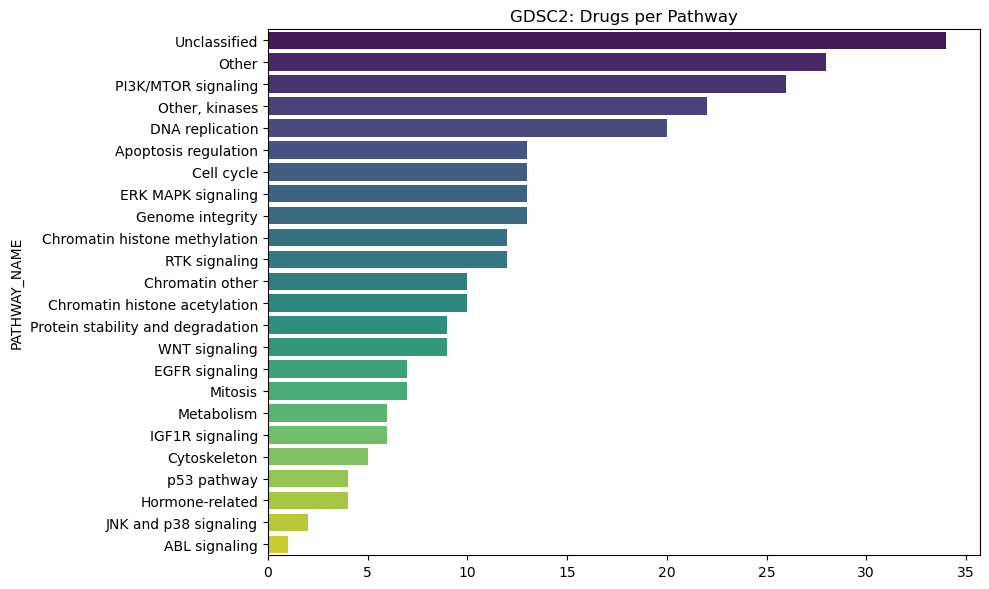

PATHWAY_NAME
Unclassified                         34
Other                                28
PI3K/MTOR signaling                  26
Other, kinases                       22
DNA replication                      20
Apoptosis regulation                 13
Cell cycle                           13
ERK MAPK signaling                   13
Genome integrity                     13
Chromatin histone methylation        12
RTK signaling                        12
Chromatin other                      10
Chromatin histone acetylation        10
Protein stability and degradation     9
WNT signaling                         9
EGFR signaling                        7
Mitosis                               7
Metabolism                            6
IGF1R signaling                       6
Cytoskeleton                          5
p53 pathway                           4
Hormone-related                       4
JNK and p38 signaling                 2
ABL signaling                         1
Name: DRUG_NAME, dtype: int

In [4]:
# pathway distribution:

pathway_counts = gdsc2.groupby('PATHWAY_NAME')['DRUG_NAME'].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=pathway_counts.values, y=pathway_counts.index, 
            hue=pathway_counts.index, palette='viridis', legend=False)
plt.title("GDSC2: Drugs per Pathway")
plt.tight_layout()
plt.savefig(BASE_DIR / "results" / "figures" / "01_pathway_distribution.png", dpi=150)
plt.show()

print(pathway_counts)

In [5]:
# load the overlap file & check pathway coverage:

overlap = pd.read_csv(PROC_DIR / "gdsc2_jump_overlap.csv")

print(f"shape: {overlap.shape}")
print(f"columns: {overlap.columns.tolist()}")
print(f"\nfirst 3 rows:")
print(overlap.head(3))

shape: (175, 4)
columns: ['drug_name', 'match_type', 'smiles', 'inchikey']

first 3 rows:
    drug_name match_type                                             smiles  \
0   Gefitinib      exact  COC1=C(C=C2C(=C1)N=CN=C2NC3=CC(=C(C=C3)F)Cl)OC...   
1  Vorinostat      exact                   C1=CC=C(C=C1)NC(=O)CCCCCCC(=O)NO   
2   Nilotinib      exact  CC1=C(C=C(C=C1)C(=O)NC2=CC(=CC(=C2)C(F)(F)F)N3...   

                      inchikey  
0  XGALLCVXEZPNRQ-UHFFFAOYSA-N  
1  WAEXFXRVDQXREF-UHFFFAOYSA-N  
2  HHZIURLSWUIHRB-UHFFFAOYSA-N  


In [6]:
# pathway coverage after overlap

gdsc2_drugs = gdsc2[['DRUG_NAME', 'PATHWAY_NAME']].drop_duplicates()
overlap_with_pathway = overlap.merge(
    gdsc2_drugs, left_on="drug_name", right_on="DRUG_NAME", how="left" 
).drop(columns="DRUG_NAME")

# pathway distribution in matched set
matched_pathways = overlap_with_pathway.groupby('PATHWAY_NAME')['drug_name'].nunique().sort_values(ascending=False)

print(f"matched drugs with pathway info: {overlap_with_pathway['PATHWAY_NAME'].notna().sum()}")
print(f"\npathway distribution (175 matched drugs):")
print(matched_pathways)

matched drugs with pathway info: 175

pathway distribution (175 matched drugs):
PATHWAY_NAME
PI3K/MTOR signaling                  19
DNA replication                      13
Other                                13
Other, kinases                       13
ERK MAPK signaling                   10
RTK signaling                        10
Genome integrity                     10
Chromatin histone methylation         9
WNT signaling                         9
Apoptosis regulation                  8
Cell cycle                            8
Chromatin other                       8
Metabolism                            6
Protein stability and degradation     6
Chromatin histone acetylation         6
EGFR signaling                        6
IGF1R signaling                       5
Hormone-related                       4
Mitosis                               4
Unclassified                          3
p53 pathway                           2
ABL signaling                         1
Cytoskeleton               

rows for matched 175 drugs: 153882
unique cell lines: 969
unique drugs: 175

LN_IC50 stats (matched drugs):
count    153882.000
mean          3.226
std           2.433
min          -8.658
25%           1.950
50%           3.504
75%           4.872
max          13.107
Name: LN_IC50, dtype: float64


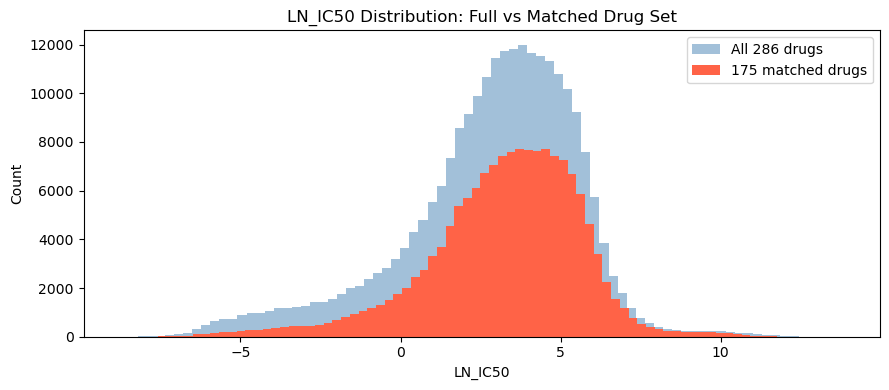

In [7]:
# LN_IC50 distribution for matched drugs only:

matched_drug_names = overlap['drug_name'].tolist()
gdsc2_matched = gdsc2[gdsc2['DRUG_NAME'].isin(matched_drug_names)].copy()

print(f"rows for matched 175 drugs: {len(gdsc2_matched)}")
print(f"unique cell lines: {gdsc2_matched['CELL_LINE_NAME'].nunique()}")
print(f"unique drugs: {gdsc2_matched['DRUG_NAME'].nunique()}")
print(f"\nLN_IC50 stats (matched drugs):")
print(gdsc2_matched['LN_IC50'].describe().round(3))

# compare distributions: full vs matched
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(gdsc2["LN_IC50"], bins=80, alpha=0.5, label='All 286 drugs', color='steelblue')
ax.hist(gdsc2_matched['LN_IC50'], bins=80, label='175 matched drugs', color='tomato')
ax.set_xlabel("LN_IC50")
ax.set_ylabel("Count")
ax.set_title("LN_IC50 Distribution: Full vs Matched Drug Set")
ax.legend()
plt.tight_layout()
plt.savefig(BASE_DIR / "results" / "figures" / "02_ic50_distribution_matched.png")
plt.show()

In [8]:
# sparsity of the drug x cell line matrix:

ic50_matrix = gdsc2_matched.pivot_table(
    index='DRUG_NAME', columns='CELL_LINE_NAME', values='LN_IC50'
)

total_entries = ic50_matrix.shape[0] * ic50_matrix.shape[1]
missing_entries = ic50_matrix.isna().sum().sum()
sparsity = missing_entries / total_entries * 100

print(f"matrix shape: {ic50_matrix.shape} (drugs x cell lines)")
print(f"total entries: {total_entries:,}")
print(f"filled entries: {total_entries - missing_entries:,}")
print(f"missing entries: {missing_entries:,}")
print(f"sparsity: {sparsity:.1f}%")

matrix shape: (175, 969) (drugs x cell lines)
total entries: 169,575
filled entries: 149,679
missing entries: 19,896
sparsity: 11.7%


In [9]:
# save the IC50 matrix and filtered GDSC2:

ic50_matrix.to_csv(PROC_DIR / "gdsc2_ic50_matrix.csv")
gdsc2_matched.to_csv(PROC_DIR / "gdsc2_matched.csv", index=False)

print(f"saved: gdsc2_ic50_matrix.csv -> {ic50_matrix.shape}")
print(f"saved: gdsc2_matched.csv -> {gdsc2_matched.shape}")

saved: gdsc2_ic50_matrix.csv -> (175, 969)
saved: gdsc2_matched.csv -> (153882, 19)


In [10]:
# load & inspect the JUMP-CP compound metadata:

compound = pd.read_csv(RAW_DIR / 'compound.csv')

print(f"shape: {compound.shape}")
print(f"\ncolumns:\n{compound.columns.tolist()}")
print(f"\nfirst 3 rows:")
print(compound.head(3))

shape: (115796, 4)

columns:
['Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_InChI', 'Metadata_SMILES']

first 3 rows:
  Metadata_JCP2022            Metadata_InChIKey  \
0   JCP2022_000001  AAAHWCWPZPSPIW-UHFFFAOYSA-N   
1   JCP2022_000002  AAAJHRMBUHXWLD-UHFFFAOYSA-N   
2   JCP2022_000004  AAANUZMCJQUYNX-UHFFFAOYSA-N   

                                      Metadata_InChI  \
0  InChI=1S/C25H31N5O2/c1-4-23-26-14-16-30(23)24-...   
1  InChI=1S/C11H13ClN2O/c12-10-4-2-9(3-5-10)8-14-...   
2  InChI=1S/C13H22N4O2S/c1-2-7-16-13(5-6-15-16)20...   

                                     Metadata_SMILES  
0  CCc1nccn1-c1cccc(C2CCCN2C(=O)c2ccc(OCCN(C)C)cc...  
1                            O=C1NCCCN1Cc1ccc(Cl)cc1  
2                   CCCn1nccc1S(=O)(=O)N1CC2CCC1CNC2  


In [11]:
# check how many of 175 drugs are present in JUMP-CP compounds

overlap_inchikeys = set(overlap['inchikey'].dropna())
jump_inchikeys = set(compound['Metadata_InChIKey'].dropna())

matched = overlap_inchikeys & jump_inchikeys
missing = overlap_inchikeys - jump_inchikeys

print(f"175 drug InChIKeys: {len(overlap_inchikeys)}")
print(f"found in JUMP-CP compound.csv: {len(matched)}")
print(f"missing from compound.csv: {len(missing)}")

if missing:
    missing_drugs = overlap[overlap['inchikey'].isin(missing)]['drug_name'].tolist()
    print(f"\nmissing drug names: {missing_drugs}")

175 drug InChIKeys: 175
found in JUMP-CP compound.csv: 98
missing from compound.csv: 77

missing drug names: ['Vinblastine', 'Cytarabine', 'Methotrexate', 'Tretinoin', 'Refametinib', 'Veliparib', 'Axitinib', 'AZD7762', 'Mirin', 'AZD8055', 'PD0325901', 'CCT007093', 'Avagacestat', 'Crizotinib', 'BI-2536', 'Irinotecan', 'BMS-536924', 'Niraparib', 'Gemcitabine', 'Tamoxifen', 'Fulvestrant', 'EPZ004777', 'Daporinad', 'AZ960', 'AZD2014', 'AZD1208', 'SN-38', 'Ruxolitinib', 'Pevonedistat', 'Uprosertib', 'LCL161', 'Alpelisib', 'EPZ5676', 'SCH772984', 'SGC-CBP30', 'GSK-LSD1', 'AZD5582', 'PFI3', 'I-BET-762', 'OTX015', 'PRT062607', 'AZD4547', 'Ibrutinib', 'Topotecan', 'Teniposide', 'Bleomycin', 'Fludarabine', 'Nelarabine', 'Dacarbazine', 'Sabutoclax', 'MG-132', 'Ulixertinib', 'ABT737', 'Afuresertib', 'AZD3759', 'AZD5363', 'AZD8186', 'Ipatasertib', 'GDC0810', 'Savolitinib', 'WEHI-539', 'AGK2', 'BIBR-1532', 'AMG-319', 'Vinorelbine', 'VX-11e', 'AZ6102', '5-azacytidine', 'CPI-637', 'AZD6482', 'AT13148'

In [12]:
# fuzzy InChIKey matching

# First block (14 chars) encodes connectivity only — ignore stereo/salt layers
overlap['inchikey_short'] = overlap['inchikey'].str[:14]
compound['inchikey_short'] = compound['Metadata_InChIKey'].str[:14]

fuzzy_matched = overlap.merge(
    compound[['Metadata_JCP2022', 'Metadata_InChIKey', 'inchikey_short']],
    on='inchikey_short', how='left'
)

found = fuzzy_matched['Metadata_JCP2022'].notna().sum()
still_missing = fuzzy_matched['Metadata_JCP2022'].isna().sum()

print(f"Exact match (previous):  98")
print(f"After fuzzy match:       {found}")
print(f"Still missing:           {still_missing}")

if still_missing > 0:
    missing_fuzzy = fuzzy_matched[fuzzy_matched['Metadata_JCP2022'].isna()]['drug_name'].tolist()
    print(f"\nStill missing after fuzzy match:\n{missing_fuzzy}")

Exact match (previous):  98
After fuzzy match:       175
Still missing:           0


In [13]:
# save the fuzzy-matched compound lookup
# keep one JCP2022 ID per drug(in case of duplicates from fuzzy match)
compound_lookup = fuzzy_matched[['drug_name', 'inchikey', 'Metadata_JCP2022', 'Metadata_InChIKey']]\
    .drop_duplicates(subset='drug_name', keep='first')

compound_lookup.to_csv(PROC_DIR / "compound_lookup.csv", index=False)

print(f"saved: compound_lookup.csv -> {compound_lookup.shape}")
print(f"\nsample:")
print(compound_lookup.head(3).to_string())

saved: compound_lookup.csv -> (175, 4)

sample:
    drug_name                     inchikey Metadata_JCP2022            Metadata_InChIKey
0   Gefitinib  XGALLCVXEZPNRQ-UHFFFAOYSA-N   JCP2022_103415  XGALLCVXEZPNRQ-UHFFFAOYSA-N
1  Vorinostat  WAEXFXRVDQXREF-UHFFFAOYSA-N   JCP2022_097466  WAEXFXRVDQXREF-UHFFFAOYSA-N
2   Nilotinib  HHZIURLSWUIHRB-UHFFFAOYSA-N   JCP2022_030328  HHZIURLSWUIHRB-UHFFFAOYSA-N


In [18]:
import pyarrow.parquet as pq

LOCAL_PATH = RAW_DIR / "profiles_var_mad_int.parquet"
jcp_ids = set(compound_lookup['Metadata_JCP2022'].tolist())

pf = pq.ParquetFile(LOCAL_PATH)
all_columns = pf.schema_arrow.names

meta_cols = [c for c in all_columns if c.startswith('Metadata_')]
feature_cols = [c for c in all_columns if not c.startswith('Metadata_')]

print(f"Metadata columns: {len(meta_cols)}")
print(f"Feature columns:  {len(feature_cols)}")

print("\nStep 1: finding matching rows...")
meta_df = pf.read(columns=meta_cols).to_pandas()
mask = meta_df['Metadata_JCP2022'].isin(jcp_ids)
print(f"Matching rows: {mask.sum()}")
meta_matched = meta_df[mask].reset_index(drop=True)

print("\nStep 2: reading features in chunks of 200...")
CHUNK = 200
feature_chunks = []

for i in range(0, len(feature_cols), CHUNK):
    cols_batch = feature_cols[i:i+CHUNK]
    batch_df = pf.read(columns=cols_batch).to_pandas()
    feature_chunks.append(batch_df[mask].reset_index(drop=True))
    print(f"  {min(i+CHUNK, len(feature_cols))}/{len(feature_cols)} features done...")

print("\nAssembling final dataframe...")
profiles_matched = pd.concat([meta_matched] + feature_chunks, axis=1)

print(f"\nShape: {profiles_matched.shape}")
print(f"Unique JCP2022 IDs: {profiles_matched['Metadata_JCP2022'].nunique()}")

Metadata columns: 4
Feature columns:  3180

Step 1: finding matching rows...
Matching rows: 18970

Step 2: reading features in chunks of 200...
  200/3180 features done...
  400/3180 features done...
  600/3180 features done...
  800/3180 features done...
  1000/3180 features done...
  1200/3180 features done...
  1400/3180 features done...
  1600/3180 features done...
  1800/3180 features done...
  2000/3180 features done...
  2200/3180 features done...
  2400/3180 features done...
  2600/3180 features done...
  2800/3180 features done...
  3000/3180 features done...
  3180/3180 features done...

Assembling final dataframe...

Shape: (18970, 3184)
Unique JCP2022 IDs: 175


In [21]:
# save the matched profiles
out_path = PROC_DIR / 'jump_profiles_matched.parquet'
profiles_matched.to_parquet(out_path, index=False)

print(f"saved: jump_profiles_matched.parquet")
print(f"shape: {profiles_matched.shape}")
print(f"file size: {out_path.stat().st_size / 1e6:.1f}")

saved: jump_profiles_matched.parquet
shape: (18970, 3184)
file size: 357.6
